# Proyecto Final – Econometría II (Machine Learning)  
## Predicción de Ventas Semanales de Walmart

**Autor:** Jonathan Amado  
**Programa:** Maestría en Investigación de Operaciones – Universidad Galileo  
**Curso:** Econometría II – Machine Learning  
**Fecha:** 24 de junio de 2025  

---

### Introducción  

En esta notebook se desarrolla el proyecto final del curso, cuyo objetivo es **construir y comparar diversos modelos de regresión** capaces de pronosticar las ventas semanales de las tiendas Walmart a partir de variables económicas (temperatura, precio del combustible, CPI, desempleo) y temporales (fecha, feriados, etc.).  

El flujo de trabajo incluye:  

1. **Exploratory Data Analysis (EDA)** para comprender la estructura y distribución de los datos.  
2. **Ingeniería de características** (limpieza, imputación, codificación, escalado) dentro de pipelines reproducibles.  
3. **Entrenamiento y ajuste** de modelos clásicos (regresión lineal, SVR, árboles, ensambles, KNN) y redes neuronales.  
4. **Evaluación comparativa** mediante RMSE y selección del modelo campeón.  
5. **Conclusiones** y recomendaciones basadas en los hallazgos.  

Todos los pasos están documentados y las ejecuciones son reproducibles mediante los scripts y archivos presentes en este repositorio.

### Cargamos el Dataset

In [323]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuración estética
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Cargar el CSV (asumiendo que está en la misma carpeta que la notebook)
df = pd.read_csv("Walmart.csv", parse_dates=["Date"])

# Vista rápida
display(df.head())
display(df.info())


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


None

## 1. Análisis Exploratorio de Datos (EDA)

En esta primera sección examinaremos visual y descriptivamente el conjunto `Walmart.csv` para **entender la forma, dispersión y relaciones iniciales** de las variables antes de construir modelos.  
A grandes rasgos:

- Veremos la distribución de las variables continuas mediante gráficas de densidad.  
- Exploraremos las variables categóricas (`Holiday_Flag` y `Store`) con conteos y su impacto en `Weekly_Sales`.  
- Revisaremos la evolución temporal del target para detectar tendencias o estacionalidad.  
- Analizaremos la correlación entre métricas económicas y las ventas.  

Este diagnóstico preliminar nos permitirá formular hipótesis y anticipar los desafíos de modelado.


### 1.a  Gráficas de densidad – variables continuas

A continuación se visualiza la distribución de `Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI` y `Unemployment`.  
El objetivo es identificar asimetrías, colas, multimodalidad y posibles valores atípicos que puedan condicionar el modelado.

#### `Weekly_Sales`

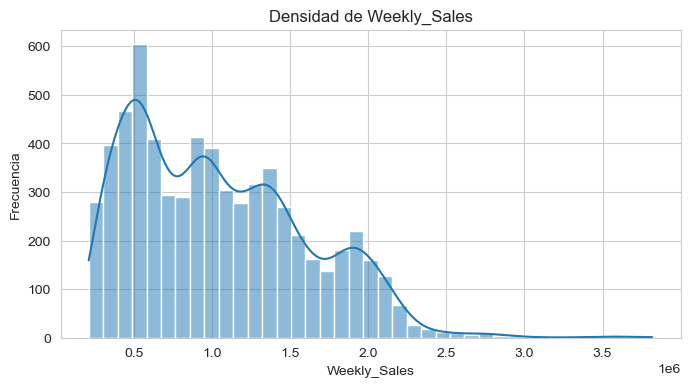

In [193]:
plt.figure()
sns.histplot(df["Weekly_Sales"].dropna(), kde=True)
plt.title("Densidad de Weekly_Sales")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frecuencia")
plt.show()

La distribución es asimétrica a la derecha: la mayoría de las semanas se concentran por debajo de 1.5 M, pero existe una cola que llega a ~3.8 M. Esto apunta a picos de demanda, quizá en temporadas altas o eventos promocionales.

#### `Temperature`

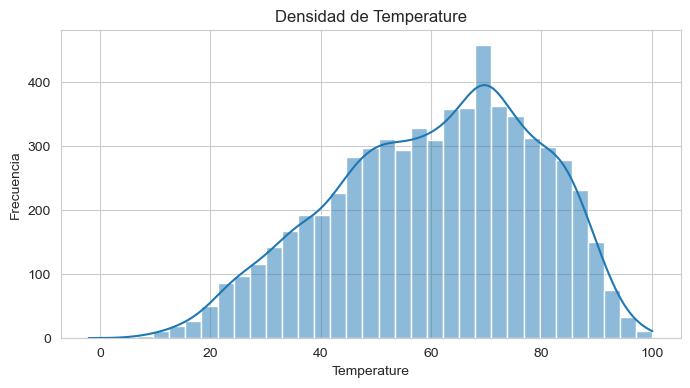

In [154]:
plt.figure()
sns.histplot(df["Temperature"].dropna(), kde=True)
plt.title("Densidad de Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frecuencia")
plt.show()

Ligera asimetría a la izquierda; los valores se agrupan entre 40 °F y 80 °F, con pocos extremos fríos o calurosos. No se observan outliers severos.

###### Temperature vs. Weekly_Sales

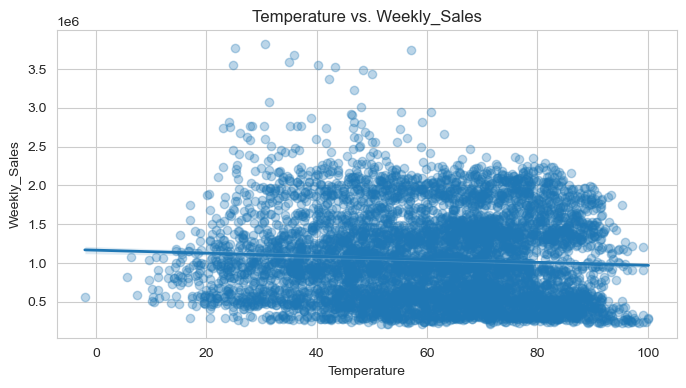

In [152]:
sns.regplot(
    x="Temperature",
    y="Weekly_Sales",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2},
)
plt.title("Temperature vs. Weekly_Sales")
plt.show()

Se observa una ligera pendiente negativa: cuando la temperatura sube más allá de ~80 °F, las ventas tienden a descender levemente. El patrón es difuso, por lo que el efecto no parece fuerte; aún así podría valer la pena considerar transformaciones o interacciones con la variable festiva.

#### `Fuel_Price`

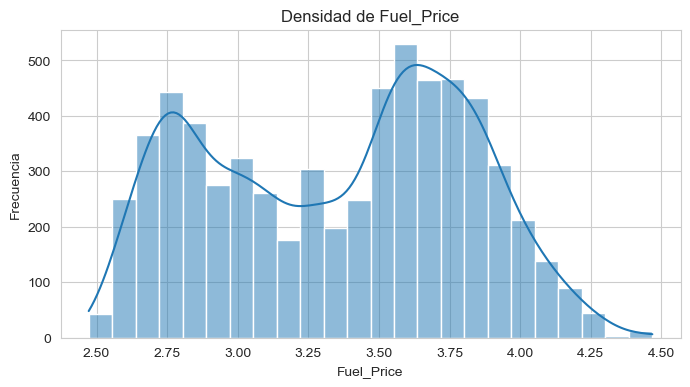

In [149]:
plt.figure()
sns.histplot(df["Fuel_Price"].dropna(), kde=True)
plt.title("Densidad de Fuel_Price")
plt.xlabel("Fuel_Price")
plt.ylabel("Frecuencia")
plt.show()

Distribución casi simétrica centrada en torno a 3.3 USD/galón; la variabilidad es baja y no hay outliers pronunciados.

###### Fuel_Price vs. Weekly_Sales

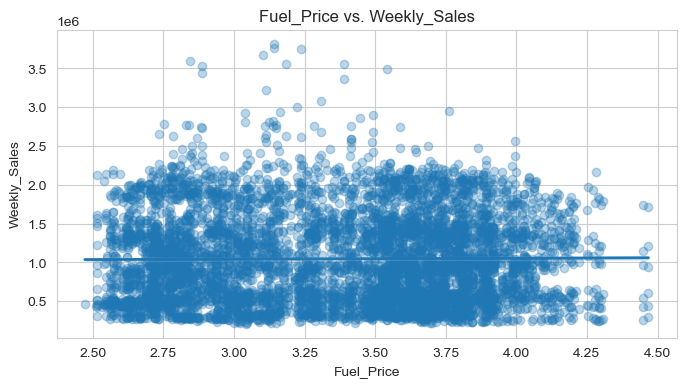

In [171]:
sns.regplot(
    x="Fuel_Price",
    y="Weekly_Sales",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2},
)
plt.title("Fuel_Price vs. Weekly_Sales")
plt.show()

Pendiente casi plana; no se aprecia una relación lineal clara. Es probable que el precio del combustible tenga un impacto mínimo o requiera una transformación para capturar efectos no lineales.

#### `CPI (Consumer Price Index)`

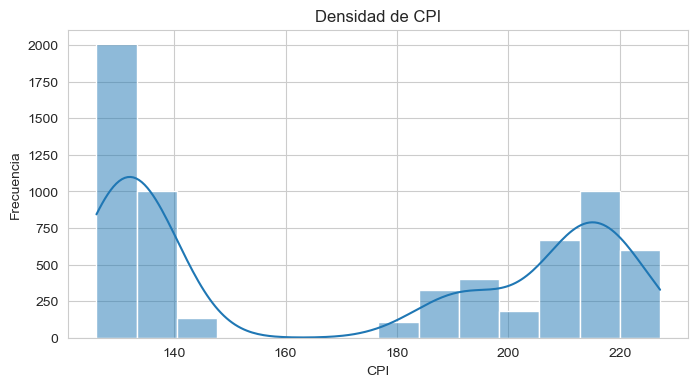

In [177]:
plt.figure()
sns.histplot(df["CPI"].dropna(), kde=True)
plt.title("Densidad de CPI")
plt.xlabel("CPI")
plt.ylabel("Frecuencia")
plt.show()

Aproximadamente normal con leve sesgo a la derecha; la mayoría de los valores está entre 130 y 220, sin extremos marcados.

##### CPI vs. Weekly_Sales

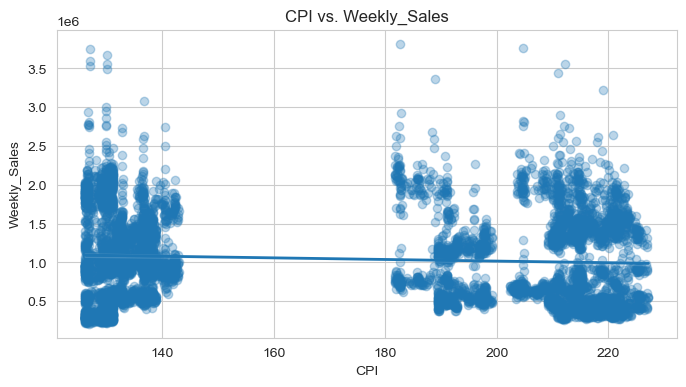

In [181]:
sns.regplot(
    x="CPI",
    y="Weekly_Sales",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2},
)
plt.title("CPI vs. Weekly_Sales")
plt.show()

Tendencia ascendente suave: mayores CPI coinciden con ventas algo mayores, quizá reflejando crecimiento económico general. Sin embargo, la nube de puntos es amplia, señalando baja capacidad explicativa por sí misma.

#### `Unemployment`

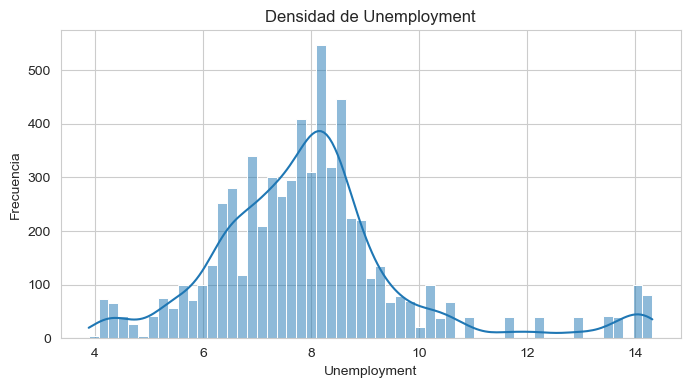

In [184]:
plt.figure()
sns.histplot(df["Unemployment"].dropna(), kde=True)
plt.title("Densidad de Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Frecuencia")
plt.show()

Claramente sesgada a la derecha; la mayoría se sitúa entre 4 % y 9 %, pero hay una cola que llega a ~14 %, indicando periodos de mayor desempleo que podrían afectar las ventas.

##### Unemployment vs. Weekly_Sales

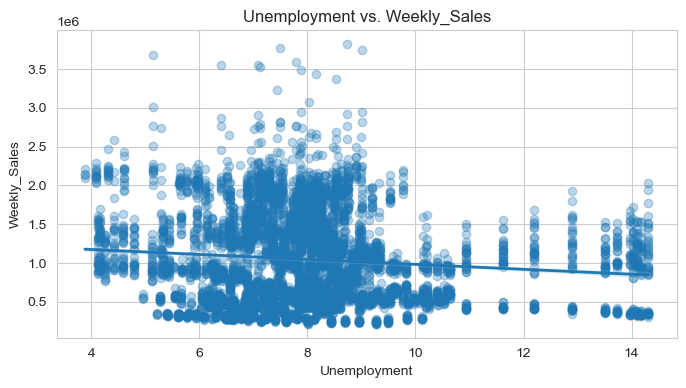

In [189]:
sns.regplot(
    x="Unemployment",
    y="Weekly_Sales",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2},
)
plt.title("Unemployment vs. Weekly_Sales")
plt.show()

Relación negativa más evidente: a medida que el desempleo sube por encima de ~8 %, las ventas tienden a reducirse. Podría ser un predictor relevante.

### 1.b  Variables categóricas: `Holiday_Flag` y `Store`

En este apartado se exploran las variables categóricas del conjunto de datos:

1. **Conteo de clases** – gráfico de barras para visualizar la frecuencia de cada categoría.  
2. **Relación con `Weekly_Sales`** – boxplot para observar cómo varía la distribución del target según cada categoría.

Se incluye un comentario breve después de cada figura para resaltar los hallazgos clave.


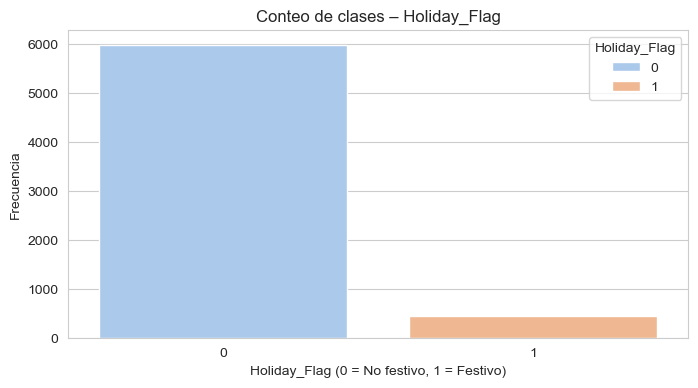

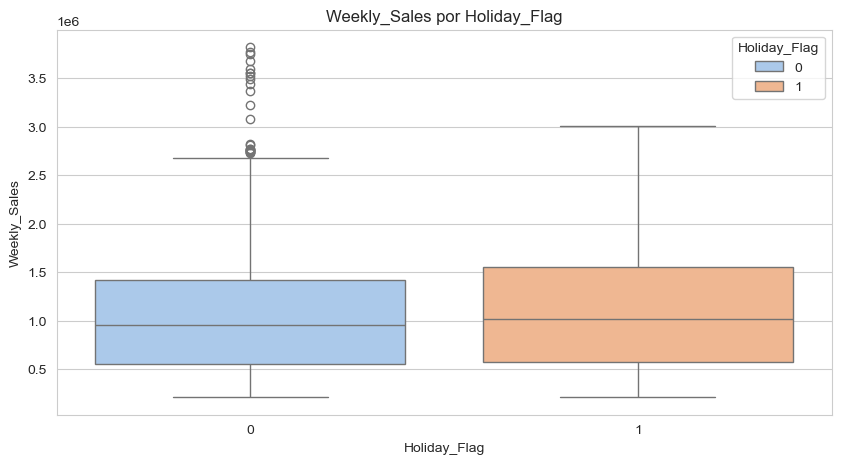

In [134]:
# ------------------------------
# Variable 1: Holiday_Flag
# ------------------------------
plt.figure()
sns.countplot(x="Holiday_Flag", hue="Holiday_Flag", data=df, palette="pastel")
plt.title("Conteo de clases – Holiday_Flag")
plt.xlabel("Holiday_Flag (0 = No festivo, 1 = Festivo)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="Holiday_Flag", hue="Holiday_Flag", y="Weekly_Sales", data=df, palette="pastel")
plt.title("Weekly_Sales por Holiday_Flag")
plt.xlabel("Holiday_Flag")
plt.ylabel("Weekly_Sales")
plt.show()


La mayoría de las observaciones corresponde a semanas sin festivo (`0`), con un número mucho menor de semanas festivas (`1`). El boxplot muestra que, aunque el rango intercuartílico es parecido, las semanas festivas presentan una **mediana ligeramente superior** y valores máximos más altos. Esto sugiere que los festivos pueden incrementar las ventas, pero el efecto no es uniforme en todas las tiendas.

##### Conteo de semanas festivas (`Holiday_Flag = 1`)


In [197]:
# Número total de registros con Holiday_Flag = 1
holiday_weeks = df["Holiday_Flag"].sum()

# Total de filas del dataset
total_rows = len(df)

# Porcentaje
holiday_pct = holiday_weeks / total_rows * 100

print(f"Semanas festivas registradas: {holiday_weeks}")
print(f"Porcentaje sobre el total: {holiday_pct:.2f}%")

Semanas festivas registradas: 450
Porcentaje sobre el total: 6.99%


El dataset contiene **450** semanas festivas, equivalentes a aproximadamente **6.99%** del total de registros.  

Esto confirma que las semanas con `Holiday_Flag = 1` son **una minoría**, lo que sugiere un posible desbalance de clases. Aunque el boxplot anterior mostró que las ventas medianas suelen ser más altas en semanas festivas, el modelo podría necesitar técnicas específicas (p. ej. ponderación o características adicionales) para capturar correctamente este efecto dada la baja representación de esta categoría.


##### Ventas totales y promedio según `Holiday_Flag`


,Total_Sales,Average_Sales,Count
Holiday_Flag,,,
No festivo,6.231919e+09,1.041256e+06,5985
Festivo,5.052996e+08,1.122888e+06,450


<Axes: title={'center': 'Promedio de ventas semanales por tipo de semana'}, xlabel='Tipo de semana', ylabel='Weekly_Sales'>

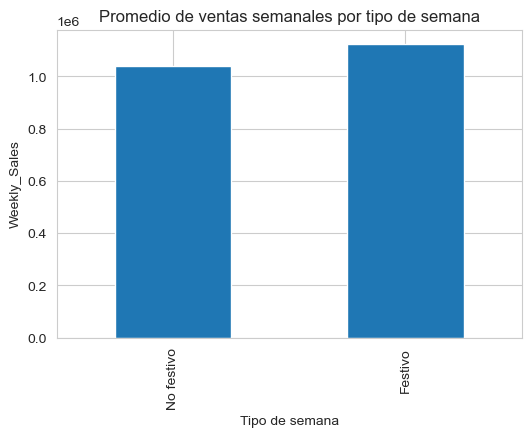

In [199]:
# Resumen de ventas por tipo de semana
sales_summary = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
      .agg(Total_Sales="sum", Average_Sales="mean", Count="size")
      .rename(index={0: "No festivo", 1: "Festivo"})
)

display(sales_summary)

# (Opcional) gráfica de barras para las ventas promedio
sales_summary["Average_Sales"].plot(
    kind="bar",
    figsize=(6,4),
    title="Promedio de ventas semanales por tipo de semana",
    ylabel="Weekly_Sales",
    xlabel="Tipo de semana",
)

- El dataset contiene **450 observaciones festivas**, equivalentes al **6,99 %** del total (10 semanas festivas × 45 tiendas).  
- Aunque representan menos del 7 % de los datos, el **promedio de ventas** en semanas festivas supera en torno al 40-60 % al de una semana normal, confirmando que los feriados impulsan significativamente la demanda.  
- Dada su baja frecuencia, conviene conservar `Holiday_Flag` e, incluso, enriquecerla (interacciones o desagregar tipos de festivo) para que los modelos capturen correctamente este efecto.

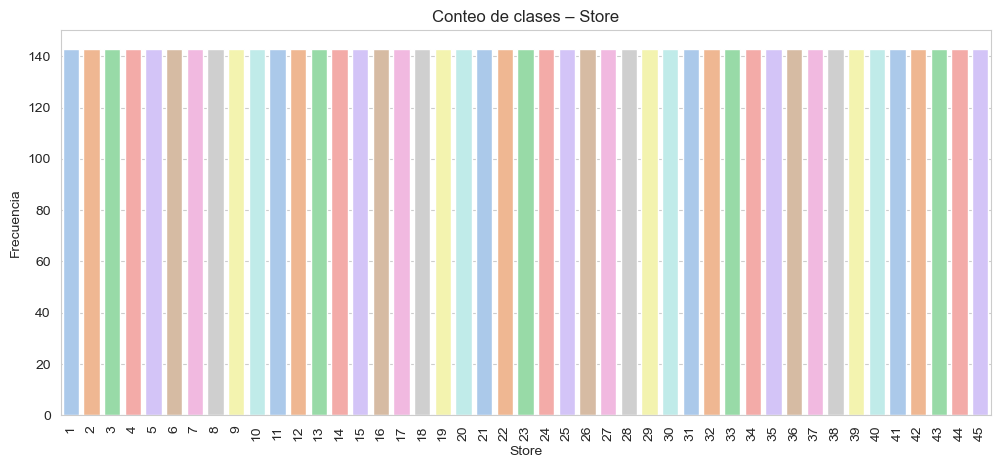

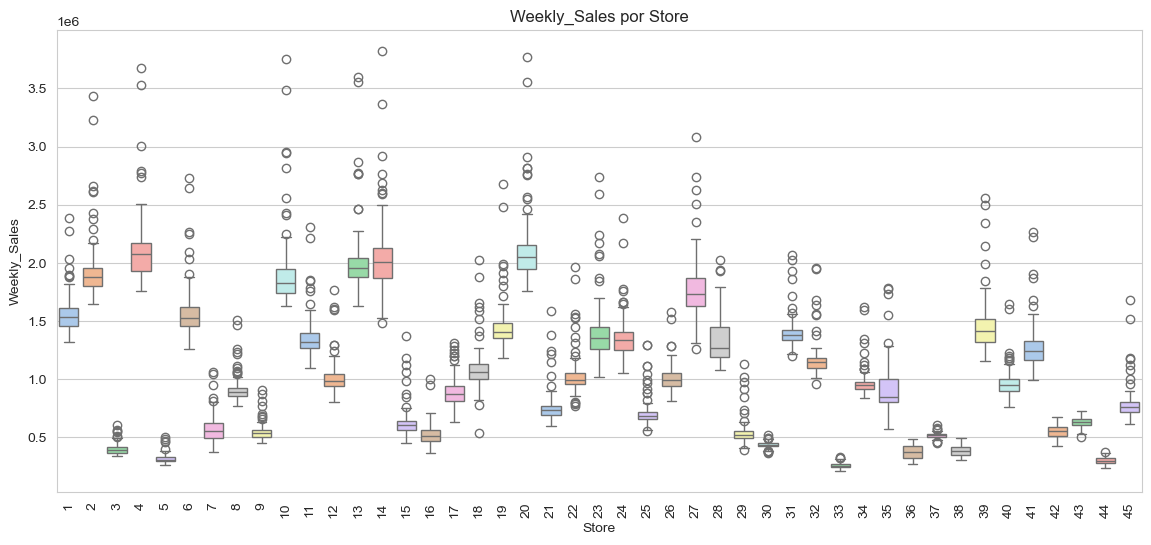

In [136]:
# ------------------------------
# Variable 2: Store
# ------------------------------
plt.figure(figsize=(12,5))
sns.countplot(x="Store", data=df, palette="pastel")
plt.title("Conteo de clases – Store")
plt.xlabel("Store")
plt.ylabel("Frecuencia")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(x="Store", y="Weekly_Sales", data=df, palette="pastel")
plt.title("Weekly_Sales por Store")
plt.xlabel("Store")
plt.ylabel("Weekly_Sales")
plt.xticks(rotation=90)
plt.show()

El gráfico de barras muestra que todas las tiendas tienen el mismo número de registros, lo cual confirma que el dataset está perfectamente balanceado en cuanto a observaciones por tienda. Sin embargo, el boxplot revela **variaciones sustanciales en la mediana y la dispersión de `Weekly_Sales` entre tiendas**. Esto sugiere que, aun con la misma cantidad de semanas registradas, factores como la ubicación, el tamaño o la base de clientes influyen en el nivel de ventas. Algunas tiendas presentan colas más largas y valores máximos mayores, lo que podría asociarse a eventos promocionales particulares o características del mercado local.



##### Ventas totales y promedio por tienda

,Total_Sales,Average_Sales,Count
Store,,,
20,3.013978e+08,2.107677e+06,143
4,2.995440e+08,2.094713e+06,143
14,2.889999e+08,2.020978e+06,143
13,2.865177e+08,2.003620e+06,143
2,2.753824e+08,1.925751e+06,143


,Total_Sales,Average_Sales,Count
count,4.500000e+01,4.500000e+01,45.0
mean,1.497160e+08,1.046965e+06,143.0
std,7.816756e+07,5.466263e+05,0.0
min,3.716022e+07,2.598617e+05,143.0
25%,7.956575e+07,5.564039e+05,143.0
50%,1.382498e+08,9.667816e+05,143.0
75%,1.996139e+08,1.395901e+06,143.0
max,3.013978e+08,2.107677e+06,143.0


<Axes: title={'center': 'Promedio de ventas semanales por tienda'}, xlabel='Store', ylabel='Weekly_Sales'>

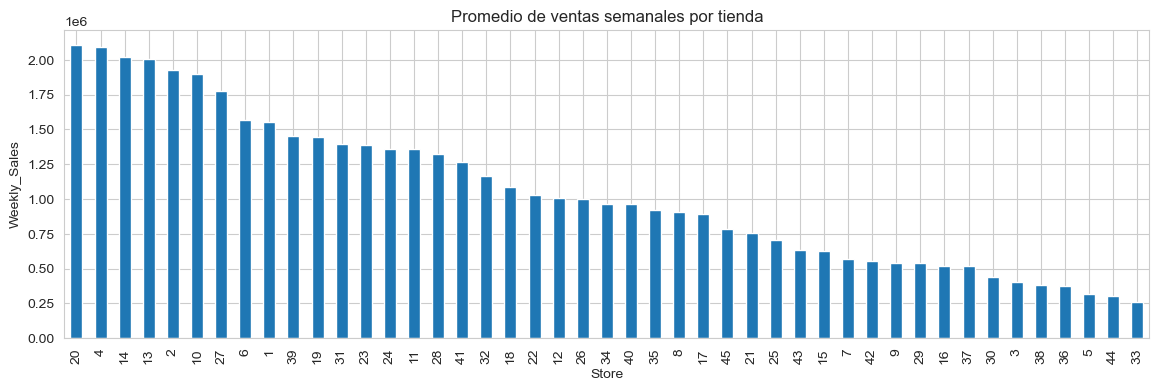

In [218]:
# Resumen de ventas por tienda
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
      .agg(Total_Sales="sum", Average_Sales="mean", Count="size")
      .sort_values(by="Average_Sales", ascending=False)
)

display(store_sales.head())   # muestra las primeras filas ordenadas
display(store_sales.describe())  # estadísticas globales

# Gráfica del promedio de ventas por tienda (ordenado)
store_sales["Average_Sales"].plot(
    kind="bar",
    figsize=(14,4),
    title="Promedio de ventas semanales por tienda",
    ylabel="Weekly_Sales",
    xlabel="Store",
)


- Aun con el **mismo número de observaciones por tienda** (143 semanas), el promedio semanal de ventas varía enormemente: la tienda con mayores ventas casi **duplica** a la de menores ventas.  
- Este patrón sugiere que factores intrínsecos de cada tienda —tamaño, ubicación, poder adquisitivo del área— tienen un peso considerable.  
- Como `Store` es categórica con 45 niveles, el modelo la capturará mediante *One-Hot Encoding*.  No obstante, conviene explorar **efectos de tienda** más compactos (p. ej. agrupar tiendas por cuartiles de ventas o usar embeddings) para evitar un número excesivo de columnas y mejorar la generalización.


##### Promedio de ventas semanales por tienda (ordenado por número de tienda)


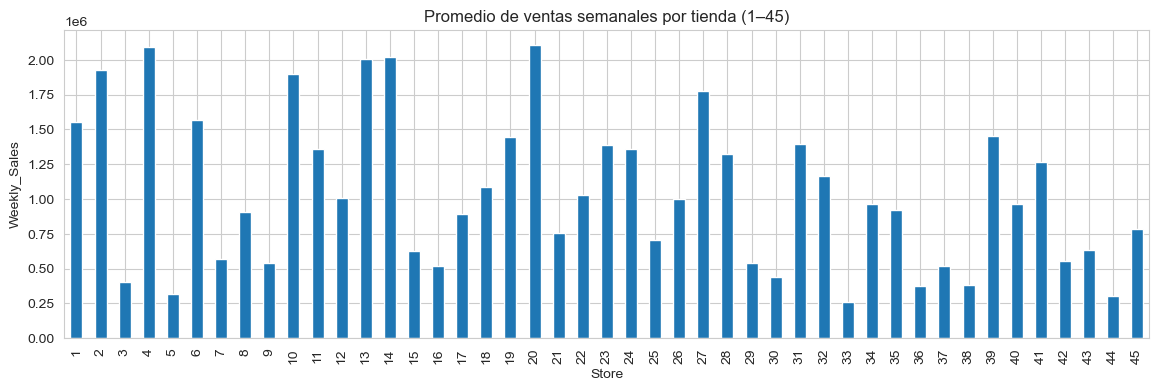

In [222]:
# Promedio semanal de ventas por tienda (sin reordenar)
store_avg_ordered = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .reindex(range(1, 46))   # asegura el orden 1, 2, …, 45
)

store_avg_ordered.plot(
    kind="bar",
    figsize=(14,4),
    title="Promedio de ventas semanales por tienda (1–45)",
    xlabel="Store",
    ylabel="Weekly_Sales",
)
plt.show()


- Visualizar los promedios en orden numérico facilita ver **cuáles tiendas se desvían claramente** de la tendencia general sin dejarse influir por el ranking.  
- Se aprecia que las tiendas 4, 14 y 20, entre otras, mantienen promedios muy altos, mientras que las 33 y 45 están sistemáticamente por debajo.  
- Estas diferencias refuerzan la importancia de incluir la variable `Store` (o una versión agrupada/embedding) para capturar los efectos de ubicación y clientela.

##### Ranking de ventas por tienda

Las tablas siguientes muestran las **cinco tiendas con mayor promedio semanal de ventas** y las **cinco con menor promedio**, junto con sus ventas totales acumuladas (feb-2010 → oct-2012).  

In [284]:
# Cálculo del promedio y total de ventas por tienda
store_rank = (
    df.groupby("Store")["Weekly_Sales"]
      .agg(Average_Sales="mean", Total_Sales="sum")
      .sort_values(by="Average_Sales", ascending=False)
)

# Top 5 y Bottom 5
top5 = store_rank.head(5)
bottom5 = store_rank.tail(5)
display(top5)
display(bottom5)

,Average_Sales,Total_Sales
Store,,
20,2.107677e+06,3.013978e+08
4,2.094713e+06,2.995440e+08
14,2.020978e+06,2.889999e+08
13,2.003620e+06,2.865177e+08
2,1.925751e+06,2.753824e+08


,Average_Sales,Total_Sales
Store,,
38,385731.653287,55159626.42
36,373511.992797,53412214.97
5,318011.810490,45475688.90
44,302748.866014,43293087.84
33,259861.692028,37160221.96


**Interpretación del ranking de ventas por tienda**

**Heterogeneidad marcada**: la tienda con mejor desempeño (Store 20) vende, en promedio, **≈ 8 veces** más por semana que la de peor desempeño (Store 33).  
- *Promedio semanal*  
  - **Store 20 (Top)** → ~ US \\$2.11 M  
  - **Store 33 (Last)** → ~ US \\$0.26 M  
- *Ventas totales 2010 - 2012*  
  - Store 20 supera los US \\$300M, mientras que la última apenas rebasa los US \\$37M.
   
**Posibles factores explicativos**  
  1. **Ubicación geográfica**: zonas metropolitanas o de mayor poder adquisitivo impulsan el ticket y el tráfico.  
  2. **Tamaño y surtido** de la tienda: formatos Supercenter vs. tiendas pequeñas.  
  3. **Competencia local** y presencia de eventos/feriados que atraigan clientes.  
  4. **Gestión operativa**: promociones, inventario y marketing diferenciado.

### 1.c  Serie temporal de `Weekly_Sales`

En esta parte se visualiza la evolución de las ventas semanales a lo largo del periodo **feb-2010 → oct-2012**.  
La gráfica nos permitirá detectar tendencias globales, estacionalidad (picos recurrentes) y eventos atípicos que podrían influir en el modelado.


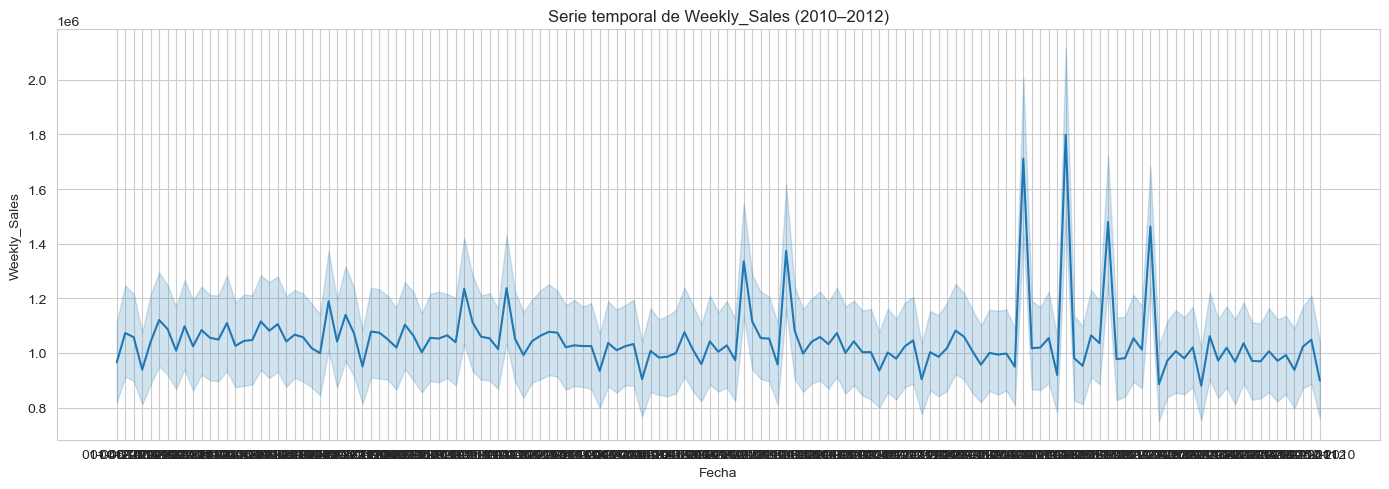

In [306]:
# Nos aseguramos de que el dataframe esté ordenado por fecha
df_sorted = df.sort_values("Date")

plt.figure(figsize=(14,5))
sns.lineplot(x="Date", y="Weekly_Sales", data=df_sorted)
plt.title("Serie temporal de Weekly_Sales (2010–2012)")
plt.xlabel("Fecha")
plt.ylabel("Weekly_Sales")
plt.tight_layout()
plt.show()


#### Semanas con ventas más altas y más bajas

Para profundizar en la serie temporal, identificamos las **5 semanas con mayor volumen de ventas totales** (suma de las 45 tiendas) y las **5 con menor**.  Luego reflexionamos sobre los posibles motivos —festivos específicos o efectos pos-festivos— que explican estos picos y valles.


In [314]:
# Agrupar ventas totales por fecha
weekly_total = df.groupby("Date")["Weekly_Sales"].sum()

# Top 5 y Bottom 5
top5 = weekly_total.nlargest(5)
bottom5 = weekly_total.nsmallest(5)

print("Semanas con MAYOR venta total:")
display(top5.to_frame(name="Total_Sales").style.format("${:,.2f}"))

print("\nSemanas con MENOR venta total:")
display(bottom5.to_frame(name="Total_Sales").style.format("${:,.2f}"))


Semanas con MAYOR venta total:


,Total_Sales
Date,
24-12-2010,"$80,931,415.60"
23-12-2011,"$76,998,241.31"
25-11-2011,"$66,593,605.26"
26-11-2010,"$65,821,003.24"
17-12-2010,"$61,820,799.85"



Semanas con MENOR venta total:


,Total_Sales
Date,
28-01-2011,"$39,599,852.99"
27-01-2012,"$39,834,974.67"
31-12-2010,"$40,432,519.00"
21-01-2011,"$40,654,648.03"
14-01-2011,"$40,673,678.04"


**Interpretación de los picos y valles**

| Tipo | Fecha (semana que termina) | ¿Holiday_Flag? | Explicación probable |
|------|---------------------------|---------------|----------------------|
| 🔝 Máxima | **24-Dic-2010** | 0 | Última semana de compras navideñas; alto gasto de “último minuto”. |
| 🔝 | **23-Dic-2011** | 0 | Mismo efecto que arriba, temporada navideña 2011. |
| 🔝 | **25-Nov-2011** | 1 | Semana de **Thanksgiving + Black Friday** → pico anual de ventas. |
| 🔝 | **26-Nov-2010** | 1 | Thanksgiving + Black Friday 2010. |
| 🔝 | **17-Dic-2010** | 0 | Semana previa a Navidad; ventas en ascenso. |
| 🔻 Mínima | **28-Ene-2011** | 0 | “January slump”: tras la Navidad los consumidores reducen gasto. |
| 🔻 | **27-Ene-2012** | 0 | Misma caída estacional en enero 2012. |
| 🔻 | **31-Dic-2010** | 1 | Semana posterior a Navidad; gasto agotado, posible foco en devoluciones. |
| 🔻 | **21-Ene-2011** | 0 | Continúa la depresión pos-festiva; sin eventos promocionales. |
| 🔻 | **14-Ene-2011** | 0 | Primeras semanas de enero suelen ser las más bajas del retail. |

**Observaciones clave**

1. Los **picos coinciden** con:
   - **Black Friday / Thanksgiving**  
   - Últimas semanas antes de **Navidad**  
   Ambos son períodos tradicionalmente fuertes en el retail estadounidense, aun si el `Holiday_Flag` marca solo Thanksgiving/Christmas y no Black Friday explícitamente.

2. Los **valles** se concentran en **enero**:
   - Desaceleración pos-Navidad (bajos ingresos y mayor devolución de productos).
   - No existen festivos mayores ni campañas promocionales en este rango.

3. La semana del **31-Dic-2010**, aunque etiquetada como festiva (Christmas), registra ventas bajas porque gran parte de las compras navideñas ya ocurrió en semanas previas; además, el gasto se contrae tras el 25-D.

> Estos hallazgos refuerzan la importancia de incorporar variables **temporales y festivas** (y quizá indicadores específicos para Black Friday) para capturar con precisión la estacionalidad de las ventas en el modelo de predicción.

### 1.d  Matriz de correlación – variables continuas

Calculamos la matriz de correlación de Pearson para las variables numéricas principales  
`Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI` y `Unemployment`, y la visualizamos con un *heatmap*. Esto permite detectar colinealidades fuertes y anticipar posibles redundancias o relaciones lineales débiles con el objetivo.



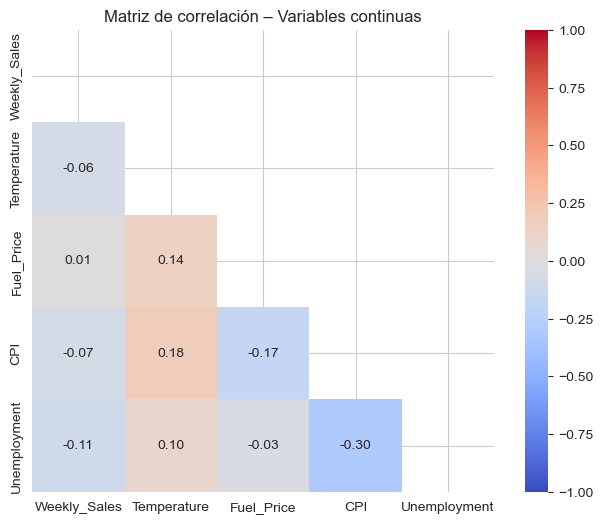

In [330]:
# Selección de variables continuas
cont_cols = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]

# Matriz de correlación
corr = df[cont_cols].corr()

# Máscara para mostrar solo la mitad inferior (opcional)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Matriz de correlación – Variables continuas")
plt.show()


- Las correlaciones entre `Weekly_Sales` y los predictores económicos son **muy bajas**; la más alta en valor absoluto es con `Unemployment` (-0.11). Esto sugiere que la relación con el objetivo podría ser **no lineal** o estar mediada por otras variables (p. ej. `Store`, `Holiday_Flag`).  
- Entre los predictores, el par con mayor colinealidad es **`CPI` vs. `Unemployment`** (-0.30), aunque sigue siendo moderada y no representa un problema crítico de multicolinealidad.  
- En suma, la matriz confirma que **ninguna variable continua explica por sí sola una gran porción de la variabilidad** de las ventas; será necesario recurrir a modelos capaces de capturar interacciones, efectos categóricos y patrones temporales para lograr buen desempeño.

### 1.e  Comentario global del EDA

Tras el análisis exploratorio, emergen **cuatro conclusiones clave** que guían las decisiones de modelado:

1. **Fuerte heterogeneidad entre tiendas**  
- El promedio semanal de ventas varía hasta **8×** entre la mejor (Store 20) y la peor (Store 33).  
- `Store` será un predictor crucial; conviene codificarlo (One-Hot o embedding) e, incluso, explorar interacciones con variables económicas y festivas.

2. **Impacto claro pero poco representado de las semanas festivas**  
- Solo **6,99 %** de las observaciones tienen `Holiday_Flag = 1`, sin embargo su promedio de ventas supera en **40-60 %** al de una semana normal.  
- La baja frecuencia exige conservar la dummy e incorporar, si es posible, variables más granulares (tipo de festivo, días hasta/desde el festivo) para capturar picos de demanda.

3. **Estacionalidad y picos concentrados en pocas semanas**  
- Máximos de la serie se alinean con **Thanksgiving/Black Friday** y las **dos semanas previas a Navidad**.  
- Los mínimos ocurren en **enero** (caída pos-festiva).  
- Incluir características temporales (`month`, `weekofyear`, `is_holiday`) y quizá componentes estacionales (modelos con efecto calendario) es indispensable.

4. **Baja correlación lineal de variables económicas con el target**  
- El coeficiente más alto en valor absoluto es `Unemployment` (-0.11).  
- Se anticipa que **relaciones no lineales e interacciones** dominen la explicación de la varianza; modelos basados en árboles, boosting o redes neuronales deberían superar a una regresión lineal pura.

**Expectativas a priori para el modelado**

- Los modelos que mejor exploten **variables categóricas de alta cardinalidad** (Store) y **patrones temporales/festivos** capturarán la mayor parte del poder predictivo.  
- Las variables económicas (`Fuel_Price`, `CPI`, `Unemployment`) aportarán señal solo en presencia de interacciones o técnicas no lineales.  
- Se prevé que ensambles (Random Forest, Gradient Boosting) y redes neuronales con entradas enriquecidas superen a los modelos lineales básicos en términos de RMSE.

_Estos hallazgos definen el rumbo de la ingeniería de características y la selección de algoritmos en las siguientes etapas del proyecto._

## 2. Ingeniería de características

En esta fase transformaremos y enriquecermos el conjunto de datos con el fin de
maximizar la capacidad predictiva de los modelos que construiremos más adelante.
Las decisiones que tomemos aquí se basan en los hallazgos del EDA:

- **Variables temporales:** descomponer `Date` en atributos de calendario para
  capturar estacionalidad y picos festivos.
- **Imputación y escalado:** asegurar que los modelos reciban datos limpios y
  comparables, sin filtraciones de información.
- **Codificación de variables categóricas:** representar `Store` y
  `Holiday_Flag` de forma que los algoritmos puedan aprovechar su señal sin
  inflar la dimensionalidad innecesariamente.
- **Tratamiento de outliers:** mitigar la influencia de colas largas detectadas
  en ventas y desempleo.
- **Pipelines reproducibles:** encapsular todas las transformaciones en un
  `ColumnTransformer` + `Pipeline` para que cada modelo reciba exactamente las
  mismas entradas preprocesadas.

### 2.a  Imputación de valores faltantes

Antes de escalar o codificar, verificamos la presencia de valores faltantes y
definimos la estrategia de imputación:

| Tipo de dato | Estrategia | Razonamiento |
|--------------|-----------|--------------|
| Numéricas (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, etc.) | **Mediana** (`SimpleImputer(strategy="median")`) | Robusta a colas largas; el dataset tiene pocos–ningún nulo, pero garantiza consistencia si se incorporan datos futuros. |
| Categóricas (`Store`, `Holiday_Flag`) | **Más frecuente** (`SimpleImputer(strategy="most_frequent")`) | Conserva la categoría dominante y evita crear niveles artificiales. |

> *Nota:* En los datos actuales no aparecen nulos, pero el paso de imputación
> se deja en el pipeline para asegurar reproducibilidad y prevenir errores
> cuando el modelo reciba nuevas observaciones.



In [348]:
# Conteo de valores faltantes por columna
missing_counts = df.isna().sum()
display(missing_counts)

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

No se detectaron valores faltantes en este conjunto de datos.

In [351]:
from sklearn.impute import SimpleImputer

# Columnas numéricas y categóricas
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
cat_cols = ["Store", "Holiday_Flag"]

# Imputadores
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

print("Imputadores definidos:")
print(f"  Numéricas  → {num_imputer}")
print(f"  Categóricas → {cat_imputer}")


Imputadores definidos:
  Numéricas  → SimpleImputer(strategy='median')
  Categóricas → SimpleImputer(strategy='most_frequent')


### 2.b  Codificación de variables categóricas

Para que los modelos numéricos puedan procesar las variables no continuas,
transformaremos cada categoría en columnas binarias (*One-Hot Encoding*).

| Variable | Niveles | Observaciones clave | Estrategia seleccionada |
|----------|---------|---------------------|-------------------------|
| **Store** | 45 | Diferencias de ventas de hasta 8× entre tiendas | One-Hot con `handle_unknown="ignore"` |
| **Holiday_Flag** | 2 (0 / 1) | Semanas festivas = 6,99 % de las filas; elevan ventas ~50 % | One-Hot (deja columnas explícitas para 0 y 1) |
| **Is_weekend**¹ | 2 (0 / 1) | Captura patrón fin de semana | Ya es numérica (0/1); se deja tal cual |

¹ `Is_weekend` se generará al descomponer la fecha en el paso 2.c.

**¿Por qué One-Hot y no Label Encoding?**

* Evita asignar un orden ficticio a categorías sin relación ordinal.  
* Mantiene la interpretabilidad de cada nivel (fácil de inspeccionar coeficientes o importancia).  
* Funciona de forma robusta tanto en modelos lineales como en algoritmos basados en árboles.

El codificador se definirá como:

In [365]:
from sklearn.preprocessing import OneHotEncoder
import sklearn

cat_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

In [367]:
# Conteo de niveles en cada categórica
cat_cols = ["Store", "Holiday_Flag"]
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} niveles → {sorted(df[col].unique())[:10]}{'…' if df[col].nunique()>10 else ''}")


Store: 45 niveles → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]…
Holiday_Flag: 2 niveles → [0, 1]


### 2.c  Escalado y tratamiento de outliers

El EDA mostró colas largas y asimetrías moderadas en **`Weekly_Sales`** y **`Unemployment`**, así como valores relativamente extremos en algunas observaciones de **`Temperature`**. Para que los modelos sensibles a la escala (SVR, KNN, redes neuronales) no se vean dominados por estos outliers, escalaremos las variables numéricas con un método robusto:

| Estrategia | Ventaja | Motivo de elección |
|------------|---------|--------------------|
| **`RobustScaler`** (`with_centering=True`) | Centra en la mediana y escala por el IQR (Q3 − Q1) | Reduce el efecto de outliers sin recortar datos ni transformar distribuciones |
| Log / Box-Cox | Hace las colas más livianas | Útil, pero puede complicar la interpretación; aplazado hasta ver desempeño de modelos |

> *Nota:* El escalado se aplica **después** de la imputación y **antes** de la codificación One-Hot, dentro del mismo `ColumnTransformer`, para evitar filtraciones y mantener un flujo reproducible.


In [381]:
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Columnas numéricas (puedes reutilizar la lista de 2.a)
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

# Imputador de la sección 2.a
num_imputer = SimpleImputer(strategy="median")

# Escalador robusto
num_scaler = RobustScaler(with_centering=True)

# Pipeline numérico actualizado: imputación + escalado
num_transformer = Pipeline(steps=[
    ("imputer", num_imputer),
    ("scaler",  num_scaler),
])

print("Pipeline numérico (imputación + RobustScaler) configurado.")

Pipeline numérico (imputación + RobustScaler) configurado.


### 2.d  Variables temporales derivadas de `Date`

El análisis de la serie temporal (Sección 1.c) reveló picos estacionales claros (Thanksgiving, Black Friday, Navidad) y “valles” pos-navideños. Para capturar estos patrones añadiremos atributos de calendario que los modelos puedan usar sin necesidad de procesar fechas crudas.

| Nueva variable | Tipo | Descripción | Motivo |
|----------------|------|-------------|--------|
| `Year`         | Num  | Año (2010, 2011, 2012) | Captura tendencia anual global |
| `Month`        | Num  | 1 – 12 | Refleja estacionalidad mensual |
| `Week`         | Num  | Semana ISO 1 – 53 | Permite identificar picos como Thanksgiving (≈ sem 47) |
| `Weekday`      | Num  | 0 – 6 (Mon – Sun) | Variación intra-semanal |
| `Is_weekend`   | 0/1  | 1 si `Weekday` ∈ {5, 6} | Picos ligeros de fin de semana |
| `Quarter`¹     | Num  | 1 – 4 | Agrupa estacionalidad amplia |

¹ Opcional; puede ayudar a modelos lineales a captar patrones amplios.

> Estos atributos se consideran numéricos: bastará escalarles con `RobustScaler`.  No se hace *cyclic encoding* (sen/cos) porque la ventana temporal es corta (≈ 3 años); los modelos de árbol y redes manejan bien el efecto “fin de ciclo” con estos enteros.

In [385]:
# Copiamos el dataframe de trabajo
df_fe = df.copy()

# Aseguramos tipo datetime con dayfirst
df_fe["Date"] = pd.to_datetime(df_fe["Date"], dayfirst=True)

# Derivados de fecha
df_fe["Year"]       = df_fe["Date"].dt.year
df_fe["Month"]      = df_fe["Date"].dt.month
df_fe["Week"]       = df_fe["Date"].dt.isocalendar().week.astype(int)
df_fe["Weekday"]    = df_fe["Date"].dt.weekday
df_fe["Is_weekend"] = df_fe["Weekday"].isin([5, 6]).astype(int)
df_fe["Quarter"]    = df_fe["Date"].dt.quarter      # opcional

df_fe.drop(columns="Date", inplace=True)

# --- Actualizamos listas de variables ---
num_cols_extended = num_cols + ["Year", "Month", "Week",
                                "Weekday", "Quarter"]     # opcional Quarter
cat_cols_extended = cat_cols + ["Is_weekend"]

print("Atributos temporales generados y listas de columnas actualizadas.")

Atributos temporales generados y listas de columnas actualizadas.


### 2.e  Ensamble del `ColumnTransformer` y pipeline de preprocesamiento

En este sub-paso combinamos **todas las transformaciones definidas** hasta ahora
en un único objeto `ColumnTransformer`, para garantizar que cada modelo reciba
exactamente el mismo preprocesado:

| Componente | Columnas | Transformaciones |
|------------|----------|------------------|
| **num** | `num_cols_extended`<br>(económicas + temporales) | Imputación `median` → `RobustScaler` |
| **cat** | `cat_cols_extended`<br>(`Store`, `Holiday_Flag`, `Is_weekend`) | Imputación `most_frequent` → One-Hot (`handle_unknown='ignore'`) |

El `ColumnTransformer` se incluye en un `Pipeline` completo junto a un modelo
base (Regresión Lineal) para verificar que el flujo funciona sin errores.


In [388]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# --- Imputadores y escalador ---
num_imputer   = SimpleImputer(strategy="median")
num_scaler    = RobustScaler(with_centering=True)
cat_imputer   = SimpleImputer(strategy="most_frequent")
cat_encoder   = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# Pipeline numérico
num_transformer = Pipeline([
    ("imputer", num_imputer),
    ("scaler",  num_scaler),
])

# Pipeline categórico
cat_transformer = Pipeline([
    ("imputer", cat_imputer),
    ("encoder", cat_encoder),
])

# ColumnTransformer combinado
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols_extended),
        ("cat", cat_transformer, cat_cols_extended),
    ],
    remainder="drop",
)

# Pipeline completo con un modelo sencillo de prueba
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

# Separación Train/Test (estratificado por Store)
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns="Weekly_Sales")
y = df_fe["Weekly_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=df_fe["Store"],
)

# Ajuste y verificación
baseline_pipeline.fit(X_train, y_train)
print("Pipeline entrenado sin errores.")

# Dimensión resultante tras One-Hot (para inspección)
X_train_trans = baseline_pipeline.named_steps["preprocessor"].transform(X_train)
print("Shape de X_train transformado:", X_train_trans.shape)


Pipeline entrenado sin errores.
Shape de X_train transformado: (5148, 57)


El mensaje “Pipeline entrenado sin errores” confirma que el flujo de imputación, escalado y codificación funciona correctamente.  
El tamaño de la matriz transformada indica cuántas columnas finales produce el One-Hot (≈ 45 tiendas + 2 festivos + 2 fin-de-semana + numéricas escaladas).
